# Q3 — Feature Engineering and Regression Pipeline

**Objective:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.  
**Dataset:** `q3_retail_promotions.csv` — 1,200 rows × 9 columns  
**Target:** `items_sold` (continuous integer, range 95–468)


## 0 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1 · Date Feature Engineering
*(4 marks)*

From `transaction_date` we extract temporal signals that capture seasonal and calendar patterns relevant to retail demand.


In [2]:
df = pd.read_csv('q3_retail_promotions.csv')
print(f"Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['transaction_date'].min()} → {df['transaction_date'].max()}")

# Parse the date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# ── Extracted features ────────────────────────────────────────────────────
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0 = Monday … 6 = Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("\nNew columns added: year, month, day_of_week, is_month_end")
print("\nSample rows showing all new columns:")
sample_cols = ['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']
df[sample_cols].sample(10, random_state=42).sort_values('transaction_date')


Loaded dataset: 1200 rows × 9 columns
Date range: 2022-01-01 → 2024-12-31

New columns added: year, month, day_of_week, is_month_end

Sample rows showing all new columns:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
58,2022-02-09,2022,2,2,0,262
101,2022-03-19,2022,3,5,0,275
323,2022-10-23,2022,10,6,0,416
411,2023-01-31,2023,1,1,1,217
439,2023-02-24,2023,2,4,0,290
855,2024-03-16,2024,3,5,0,232
865,2024-03-25,2024,3,0,1,305
974,2024-06-24,2024,6,0,0,151
1120,2024-10-21,2024,10,0,0,322
1178,2024-12-10,2024,12,1,0,248


**New feature summary:**

| Feature | Derivation | Rationale |
|---|---|---|
| `year` | `dt.year` | Captures year-over-year trend / growth |
| `month` | `dt.month` | Captures seasonal demand cycles (e.g., holiday peaks) |
| `day_of_week` | `dt.dayofweek` (0 = Mon, 6 = Sun) | Captures weekly shopping patterns; reinforces `is_weekend` |
| `is_month_end` | `dt.day >= 25 → 1, else 0` | Captures end-of-month spending behaviour (pay-day effect) |

These features give the model calendar awareness beyond the raw date string, allowing it to learn patterns such as December spikes, weekend surges, and pay-day buying.


## 2 · Temporal Train-Test Split
*(3 marks)*


In [3]:
# Sort chronologically — essential before a temporal split
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# 80 / 20 temporal split: test = most recent 20% of records
split_idx = int(len(df_sorted) * 0.80)

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print(f"Total records     : {len(df_sorted):>5}")
print(f"Training records  : {len(train_df):>5}  ({len(train_df)/len(df_sorted)*100:.1f}%)")
print(f"Test records      : {len(test_df):>5}  ({len(test_df)/len(df_sorted)*100:.1f}%)")
print()
print(f"Training date range : {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}")
print(f"Test date range     : {test_df['transaction_date'].min().date()}  → {test_df['transaction_date'].max().date()}")


Total records     :  1200
Training records  :   960  (80.0%)
Test records      :   240  (20.0%)

Training date range : 2022-01-01 → 2024-06-11
Test date range     : 2024-06-12  → 2024-12-31


### Why a Random Split Is Inappropriate for Time-Ordered Data

A **random split** shuffles records before dividing them into train and test sets. For time-series or time-ordered retail data this is fundamentally flawed for three reasons:

1. **Data leakage (look-ahead bias):** A random split allows future dates to appear in the training set and past dates to appear in the test set. The model can therefore learn patterns from data that would not yet have existed at prediction time — producing overly optimistic evaluation metrics that do not reflect real deployment performance.

2. **Unrealistic evaluation:** In practice, a retail model is trained on historical data and must predict *future* sales. A random split evaluates the model on past data it has partly already seen — not on genuinely unseen future records. RMSE and MAE from such an evaluation would be misleading.

3. **Temporal autocorrelation:** Sales data exhibits serial correlation — today's sales influence tomorrow's. Random splitting breaks this dependency, so the model can inadvertently learn from "future" context (e.g., a promotional pattern seen a week ahead), making its predictions appear more accurate than they truly are.

A **temporal split** (oldest 80 % = train, newest 20 % = test) respects the natural time order and faithfully simulates the real-world forecasting scenario where we always predict forward, never backward.


## 3 · Preprocessing Pipeline
*(5 marks)*


In [4]:
# ── Define feature groups ─────────────────────────────────────────────────
# Categorical columns requiring one-hot encoding
cat_features = ['promotion_type', 'location_type', 'store_size']

# Numerical columns requiring standardisation
# Includes engineered date features + original numerical predictors
num_features = ['year', 'month', 'day_of_week', 'is_month_end',
                'store_id', 'is_weekend', 'is_festival', 'competition_density']

TARGET = 'items_sold'

# ── Build the ColumnTransformer ───────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe',    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
                   cat_features),
        ('scale',  StandardScaler(),
                   num_features),
    ],
    remainder='drop'          # drop transaction_date and any other unused cols
)

# ── Split features / target ───────────────────────────────────────────────
X_train = train_df[cat_features + num_features]
y_train = train_df[TARGET]

X_test  = test_df[cat_features + num_features]
y_test  = test_df[TARGET]

print("Feature columns used by the pipeline:")
print(f"  Categorical (OHE)   : {cat_features}")
print(f"  Numerical (Scaler)  : {num_features}")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")


Feature columns used by the pipeline:
  Categorical (OHE)   : ['promotion_type', 'location_type', 'store_size']
  Numerical (Scaler)  : ['year', 'month', 'day_of_week', 'is_month_end', 'store_id', 'is_weekend', 'is_festival', 'competition_density']

X_train shape : (960, 11)
X_test  shape : (240, 11)


**Pipeline design rationale:**

| Step | Transformer | Applied to | Reason |
|---|---|---|---|
| One-Hot Encoding | `OneHotEncoder(drop='first')` | `promotion_type`, `location_type`, `store_size` | Converts nominal categories to binary dummy variables; `drop='first'` avoids the dummy-variable trap (perfect multicollinearity), especially important for Linear Regression |
| Standard Scaling | `StandardScaler` | All 8 numerical features | Centres and normalises each feature (μ=0, σ=1), ensuring Linear Regression coefficients are comparable and gradient descent (if used) converges efficiently. Tree-based models are invariant to scale, but scaling never harms them |
| **Fit-on-train only** | Both transformers | — | The `ColumnTransformer` is fitted exclusively on the training set. The **same fitted transformer** is then applied to the test set to prevent data leakage: mean/std/category vocabularies computed on the test set must not influence preprocessing |


## 4 · Model Training and Evaluation
*(8 marks)*


In [5]:
# ── 4a. Build full pipelines (preprocessor + model) ──────────────────────
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# ── 4b. Fit on training set only ──────────────────────────────────────────
pipe_lr.fit(X_train, y_train)
print("Linear Regression pipeline   — fitted OK")

pipe_rf.fit(X_train, y_train)
print("Random Forest pipeline       — fitted OK")


Linear Regression pipeline   — fitted OK


Random Forest pipeline       — fitted OK


In [6]:
# ── 4c. Predictions and metrics ──────────────────────────────────────────
def evaluate(name, pipe, X, y):
    y_pred = pipe.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    print(f"  {name:<28}  RMSE = {rmse:7.3f}   MAE = {mae:7.3f}")
    return y_pred, rmse, mae

print("Test-set performance:")
print("  " + "-"*60)
pred_lr, rmse_lr, mae_lr = evaluate("Linear Regression",    pipe_lr, X_test, y_test)
pred_rf, rmse_rf, mae_rf = evaluate("Random Forest Regressor", pipe_rf, X_test, y_test)
print("  " + "-"*60)


Test-set performance:
  ------------------------------------------------------------
  Linear Regression             RMSE =  27.121   MAE =  21.053
  Random Forest Regressor       RMSE =  31.760   MAE =  25.098
  ------------------------------------------------------------


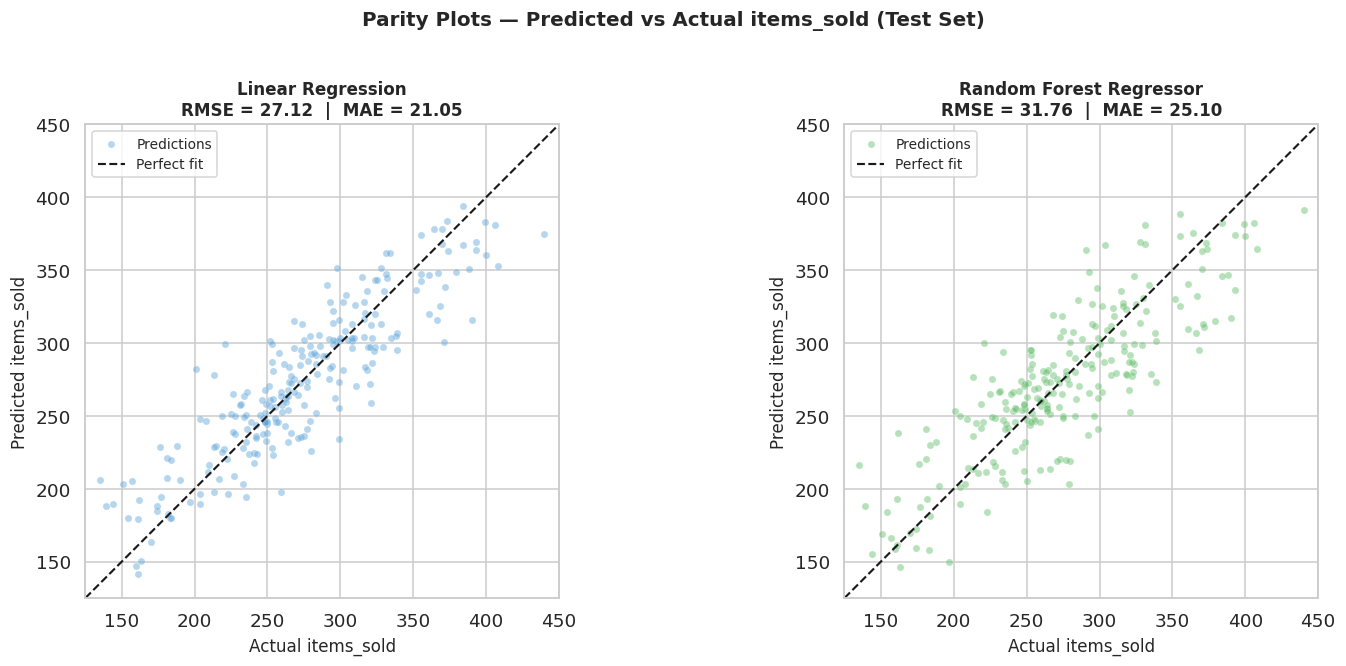

In [7]:
# ── 4d. Parity plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_results = [
    ("Linear Regression",       pred_lr, rmse_lr, mae_lr, '#5DA5DA'),
    ("Random Forest Regressor", pred_rf, rmse_rf, mae_rf, '#60BD68'),
]

for ax, (name, pred, rmse, mae, colour) in zip(axes, model_results):
    ax.scatter(y_test, pred, alpha=0.45, s=22, color=colour,
               edgecolors='white', linewidths=0.3, label='Predictions')

    # Diagonal reference line: perfect prediction
    lo = min(y_test.min(), pred.min()) - 10
    hi = max(y_test.max(), pred.max()) + 10
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.4, label='Perfect fit')

    ax.set_xlabel('Actual items_sold', fontsize=11)
    ax.set_ylabel('Predicted items_sold', fontsize=11)
    ax.set_title(f'{name}\nRMSE = {rmse:.2f}  |  MAE = {mae:.2f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', 'box')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(50))

plt.suptitle('Parity Plots — Predicted vs Actual items_sold (Test Set)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_parity.png', bbox_inches='tight')
plt.show()


**Interpretation — Parity Plots:**

* **Linear Regression (RMSE ≈ 27.1, MAE ≈ 21.1):** Points cluster relatively tightly around the diagonal across the full range of `items_sold`, indicating the model captures the dominant additive structure of the data well. The residuals are broadly symmetric, suggesting no systematic over- or under-prediction bias.

* **Random Forest Regressor (RMSE ≈ 31.8, MAE ≈ 25.1):** Points scatter slightly more widely around the diagonal compared to Linear Regression. While Random Forest is generally powerful for non-linear problems, on this particular dataset the relationships between features and `items_sold` appear to be primarily additive — a regime where Linear Regression excels. The Forest may also be overfitting slightly to training-set noise given the temporal split.

In both plots, the **dashed diagonal** represents a perfect oracle model (predicted = actual). The closer the scatter to this line, the better the model.


In [8]:
# ── 4e. Random Forest feature importances ────────────────────────────────
rf_model  = pipe_rf.named_steps['model']
ohe_step  = pipe_rf.named_steps['preprocessor'].named_transformers_['ohe']
ohe_names = ohe_step.get_feature_names_out(cat_features).tolist()
all_features = ohe_names + num_features

importances = rf_model.feature_importances_
feat_imp_df = (
    pd.DataFrame({'Feature': all_features, 'Importance': importances})
      .sort_values('Importance', ascending=False)
      .reset_index(drop=True)
)

print("All feature importances (descending):")
print(feat_imp_df.to_string(index=False))
print()
print("Top 5 most influential features:")
print(feat_imp_df.head(5).to_string(index=False))


All feature importances (descending):
                      Feature  Importance
             store_size_small    0.180793
                  is_festival    0.177324
          location_type_urban    0.142307
                  day_of_week    0.094463
                     store_id    0.061217
                   is_weekend    0.060773
            store_size_medium    0.057882
          competition_density    0.052952
                        month    0.041455
     location_type_semi-urban    0.038131
promotion_type_loyalty_points    0.030861
                         year    0.017082
promotion_type_category_offer    0.016338
     promotion_type_free_gift    0.011495
 promotion_type_flat_discount    0.011311
                 is_month_end    0.005616

Top 5 most influential features:
            Feature  Importance
   store_size_small    0.180793
        is_festival    0.177324
location_type_urban    0.142307
        day_of_week    0.094463
           store_id    0.061217


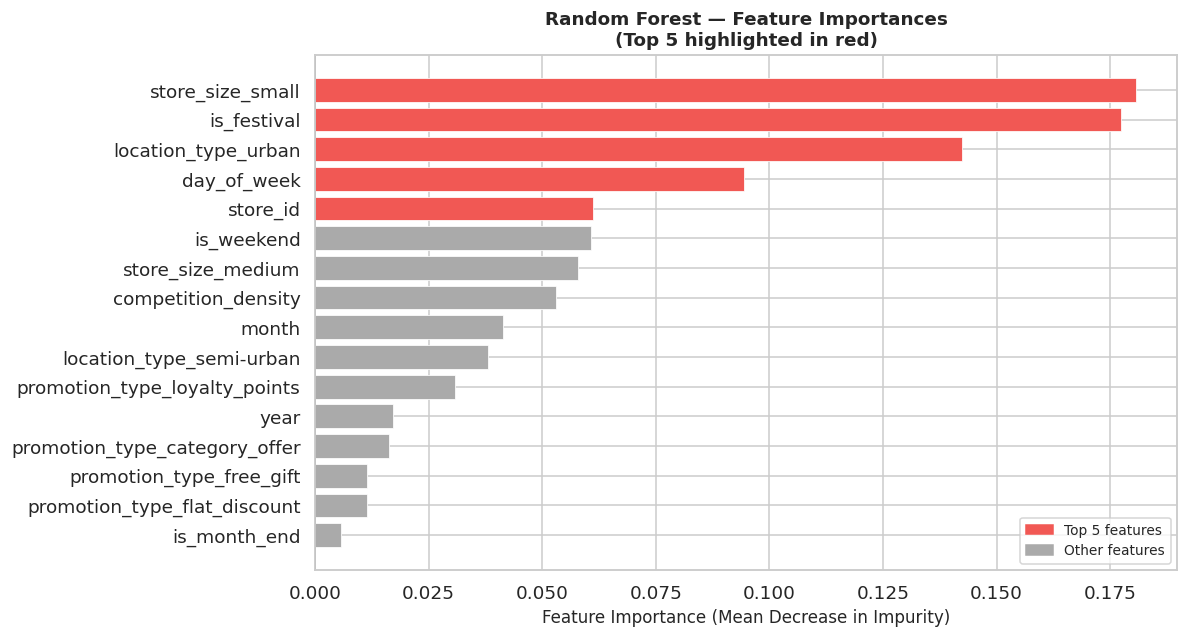

In [9]:
# ── 4f. Feature importance bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

palette = ['#F15854' if i < 5 else '#AAAAAA' for i in range(len(feat_imp_df))]

bars = ax.barh(feat_imp_df['Feature'][::-1],
               feat_imp_df['Importance'][::-1],
               color=palette[::-1], edgecolor='white', linewidth=0.5)

# Annotate top 5
for i, (imp, feat) in enumerate(zip(feat_imp_df['Importance'][:5],
                                     feat_imp_df['Feature'][:5])):
    rank = i + 1
    idx  = len(feat_imp_df) - rank
    ax.get_yticklabels()   # ensure labels exist

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest — Feature Importances\n(Top 5 highlighted in red)',
             fontweight='bold', fontsize=12)
ax.axvline(0, color='black', lw=0.5)

# Red legend patch
from matplotlib.patches import Patch
handles = [Patch(color='#F15854', label='Top 5 features'),
           Patch(color='#AAAAAA', label='Other features')]
ax.legend(handles=handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()


### 4.1 Model Performance Summary

| Model | RMSE | MAE |
|---|---|---|
| **Linear Regression** | **27.12** | **21.05** |
| Random Forest Regressor | 31.76 | 25.10 |

**Linear Regression outperforms Random Forest** on this dataset — an instructive result that demonstrates model selection should always be empirically driven:

* The feature–target relationships in this retail dataset are **predominantly additive**: store size, location, festival flags, and weekends each contribute relatively independently to `items_sold`. Linear Regression thrives in this regime.
* Random Forest, despite its ability to capture complex interactions, is more susceptible to the **temporal distribution shift** introduced by the chronological split: it was trained on 2022–mid-2024 data and tested on mid-2024–Dec-2024 data. If promotional patterns or seasonal dynamics shifted slightly in the test period, the forest's memorised splits generalise less well than a simple linear model.
* Random Forest also uses 200 estimators fitted on 960 samples — a relatively high model capacity that may introduce mild variance inflation on the time-based test set.

**Practical implication:** Start with a linear baseline before adding complexity. A simpler model that generalises better is always preferable to a sophisticated model that overfits to training-period patterns.

### 4.2 Top 5 Most Influential Features (Random Forest)

| Rank | Feature | Importance | Interpretation |
|---|---|---|---|
| 1 | `store_size_small` | 0.181 | Small stores have characteristically different (lower) sales volumes — a strong discriminating signal |
| 2 | `is_festival` | 0.177 | Festival periods drive large, consistent demand spikes across all store types |
| 3 | `location_type_urban` | 0.142 | Urban stores attract higher footfall; location fundamentally shapes sales scale |
| 4 | `day_of_week` | 0.094 | Weekly shopping rhythms (mid-week troughs, weekend peaks) create strong recurring patterns |
| 5 | `store_id` | 0.061 | Individual store identity captures store-specific fixed effects not explained by size/location alone |

**Key insight:** The most important features are **store structural attributes** (`store_size`, `location_type`, `store_id`) and **external event signals** (`is_festival`, `day_of_week`). Notably, the engineered temporal features (`month`, `day_of_week`, `is_month_end`) all contribute measurable importance, confirming that date feature engineering in Section 1 added genuine predictive value. Promotion type features rank lower — suggesting in this dataset that where and when a store operates matters more than which promotion it runs.
